# 📦 백카톤 리스크 분석 노트북

자동차 애프터마켓 부품 수출 회사의 발주·입고·재고·선적 데이터로
**선적에 못 실리고 다음 배로 넘어가는 물량(백카톤)** 의 원인을 찾고,
**언제까지 얼마나 발주해야 하는지** 정하는 과정을 SQL로 따라갑니다.

> ⚠️ 모든 데이터는 실제 ERP와 **컬럼 구조만 같은 가상 데이터**입니다.

| 단계 | 질문 | SQL 파일 |
|---|---|---|
| 1 | 데이터를 어떻게 맞춰 볼까? | `02_clean.sql` |
| 2 | 백카톤은 왜 생겼을까? | `03_bc_causes.sql` |
| 3 | 언제까지, 얼마나 발주해야 할까? | `04_order_timing.sql`, `05_recommend.sql` |

## 0. 준비
`scm.db` 가 없으면 `run_all.py` 로 가상 데이터를 만들고 뷰까지 생성합니다.

In [1]:
import sqlite3, subprocess, sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB = ROOT / "scm.db"
if not DB.exists():
    subprocess.run([sys.executable, ROOT / "scripts" / "run_all.py"], check=True)
con = sqlite3.connect(DB)

def sql(q):
    """SQL 을 실행해서 표(DataFrame)로 돌려준다"""
    return pd.read_sql_query(q, con)

# 한글 폰트 + 차트 기본 스타일
for name in ["Noto Sans CJK KR", "AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if any(name in f.name for f in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = name; break
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlelocation": "left", "axes.titleweight": "bold",
                     "figure.dpi": 110})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#c9c8c1"
pd.set_option("display.max_columns", 20)

## 1. 데이터 준비

### 1-① 데이터는 3종류
발주·입고 엑셀은 열 구조가 같아서 한 표(`raw_order_lines`)에 넣고 `extract_type` 으로 구분합니다.

In [2]:
sql("""
SELECT extract_type AS 구분, extract_month AS 기준월, COUNT(*) AS 줄수
FROM raw_order_lines
GROUP BY 1, 2 ORDER BY 2, 1
""")

,구분,기준월,줄수
0,발주,2024-02,222
1,입고,2024-02,205
2,발주,2024-04,244
3,입고,2024-04,250


### 1-② 품번 매칭 키
같은 품번이 파일마다 `0K19A-86-609`, `0K19A86609` 처럼 다르게 적혀 있어서
하이픈·공백·앞자리 0을 없앤 **매칭 키(`part_key`)** 로 맞춥니다.

In [3]:
sql("""
SELECT part_key AS 매칭키,
       GROUP_CONCAT(DISTINCT part_no) AS 원래_품번들,
       COUNT(DISTINCT part_no)        AS 표기_수
FROM order_lines
GROUP BY part_key
HAVING COUNT(DISTINCT part_no) > 1
LIMIT 5
""")

,매칭키,원래_품번들,표기_수
0,15427E9912,"15427-E9912,15427E9912",2
1,1547004491,"15470-04491,1547004491",2
2,17011J5876,"17011-J5876,17011J5876",2
3,2155262988,"21552-62988,2155262988",2
4,38789A2095,"38789-A2095,38789A2095",2


### 1-③ P/I 번호로 줄 유형 나누기
- **NEW** 신규 발주 · **BC_CARRY** 백카톤 이월 · **BACKORDER** 백오더 · **PLAN** 계획발주
- 백카톤 중 입고일 ≤ 발주일이면 창고에 있던 걸 다시 쓴 **재사용**, 아니면 **재구매**

In [4]:
sql("""
SELECT line_type AS 유형, COALESCE(bc_kind, '-') AS 백카톤_종류, COUNT(*) AS 줄수
FROM order_lines
WHERE extract_type = '발주'
GROUP BY 1, 2 ORDER BY 3 DESC
""")

,유형,백카톤_종류,줄수
0,NEW,-,245
1,BC_CARRY,BC_REPURCHASE,113
2,PLAN,-,60
3,BC_CARRY,BC_REUSE,26
4,BACKORDER,-,13
5,BC_CARRY,BC_OPEN,9


## 2. 백카톤은 왜 생겼을까?

백카톤 줄의 이전PI에서 `BC` 를 떼면 **원래 실렸어야 할 선적 P/I** 가 나옵니다.
그 선적일과 이 줄의 발주일·입고일을 비교해 원인을 나눕니다.

| 원인 | 기준 |
|---|---|
| A. 입고 지연 | 발주는 선적 전, 입고가 선적 후 |
| B. 발주 지연 | 선적이 끝난 뒤 발주 |
| C. 입고됐는데 누락 | 선적 전에 입고됐는데 안 실림 |
| D. 재사용 | 창고 백카톤을 다음 선적에 배정 |

In [5]:
causes = sql("""
SELECT bc_cause AS 원인,
       COUNT(*) AS 줄수,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS 비율,
       ROUND(SUM(po_amount) / 1000000.0, 1) AS 금액_백만원
FROM bc_lines
GROUP BY bc_cause ORDER BY 줄수 DESC
""")
causes

,원인,줄수,비율,금액_백만원
0,A. 입고 지연,76,51.4,72.1
1,D. 백카톤 재사용,26,17.6,42.5
2,C. 입고됐는데 누락,19,12.8,45.9
3,B. 발주 지연,18,12.2,11.9
4,미입고,9,6.1,10.1


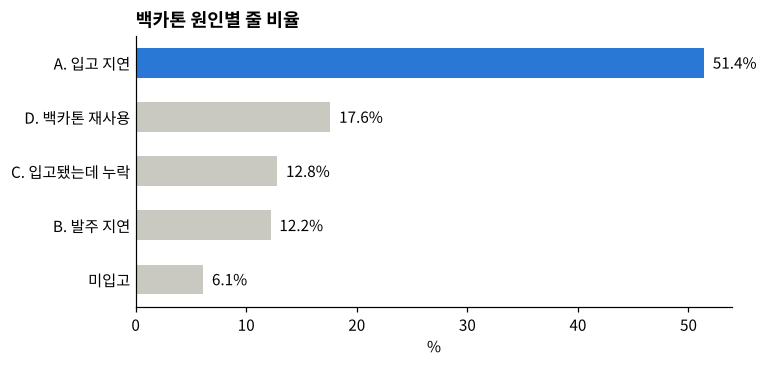

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
d = causes[::-1]
ax.barh(d["원인"], d["비율"], color=[BLUE if c.startswith("A") else GRAY for c in d["원인"]], height=0.55)
for y, v in enumerate(d["비율"]):
    ax.text(v + 0.8, y, f"{v}%", va="center")
ax.set_title("백카톤 원인별 줄 비율"); ax.set_xlabel("%"); ax.tick_params(axis="y", length=0)
plt.show()

→ **A. 입고 지연**이 가장 큼 → 거래처별로 얼마나 늦는지 확인

### 2-② 거래처별 입고 지연율
지연율 = 입고 지연으로 빠진 줄 / (제때 실린 줄 + 빠진 줄). 10줄 이상 거래처만.

In [7]:
sql("""
SELECT supplier AS 거래처, on_time_lines AS 제때_실림, late_lines AS 늦어서_빠짐,
       late_rate_pct AS 지연율, avg_days_late AS 평균_지연일, avg_lead_days AS 평균_리드타임
FROM supplier_delay
ORDER BY late_rate_pct DESC
LIMIT 10
""")

,거래처,제때_실림,늦어서_빠짐,지연율,평균_지연일,평균_리드타임
0,공급사16,5,7,58.3,15.7,19.3
1,공급사18,5,6,54.5,19.5,17.0
2,공급사01,7,7,50.0,9.0,18.4
3,공급사07,8,7,46.7,20.3,17.5
4,공급사17,8,7,46.7,8.3,16.5
5,공급사03,6,4,40.0,22.5,19.4
6,공급사21,9,5,35.7,9.6,12.8
7,공급사02,11,6,35.3,13.0,12.3
8,공급사19,12,5,29.4,4.8,18.3
9,공급사10,9,3,25.0,16.3,7.6


### 2-③ C. 입고됐는데 누락 — 선적 며칠 전에 들어왔나?
오래전에 들어왔는데 안 실렸다면 작업 시간보다 **재고 확인·배정** 문제일 가능성이 큽니다.

In [8]:
sql("""
SELECT CASE WHEN gap <= 2  THEN '1) 0~2일 전'
            WHEN gap <= 7  THEN '2) 3~7일 전'
            WHEN gap <= 14 THEN '3) 8~14일 전'
            ELSE                '4) 15일 이상 전' END AS 입고_시점,
       COUNT(*) AS 줄수,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS 비율
FROM (SELECT CAST(JULIANDAY(missed_ship_date) - JULIANDAY(rcv_date) AS INTEGER) AS gap
      FROM bc_lines WHERE bc_cause = 'C. 입고됐는데 누락')
GROUP BY 1 ORDER BY 1
""")

,입고_시점,줄수,비율
0,1) 0~2일 전,2,10.5
1,2) 3~7일 전,6,31.6
2,3) 8~14일 전,7,36.8
3,4) 15일 이상 전,4,21.1


## 3. 언제까지, 얼마나 발주해야 할까?

### 3-① 거래처별 P80 리드타임
P80 = "이 거래처 물건은 10번 중 8번은 이 일수 안에 들어온다".
입고 20줄 미만 거래처는 전체 P80을 씁니다.

**발주 기한 = 선적일 − P80 리드타임**

In [9]:
sql("SELECT supplier AS 거래처, n AS 입고줄수, avg_lead AS 평균, p80_lead AS P80, basis AS 기준 FROM supplier_lead ORDER BY n DESC LIMIT 8")

,거래처,입고줄수,평균,P80,기준
0,공급사13,26,13.1,23,거래처 기준
1,공급사23,24,8.4,14,거래처 기준
2,공급사19,16,18.3,18,전체 기준(표본 부족)
3,공급사17,15,16.5,18,전체 기준(표본 부족)
4,공급사09,14,7.4,18,전체 기준(표본 부족)
5,공급사10,14,7.6,18,전체 기준(표본 부족)
6,공급사02,13,12.3,18,전체 기준(표본 부족)
7,공급사05,12,10.9,18,전체 기준(표본 부족)


### 3-② 이 기한이 의미 있는 기준일까? — 과거 데이터로 검증

In [10]:
check = sql("""
SELECT CASE ordered_late WHEN 1 THEN '기한보다 늦게 발주' ELSE '기한 안에 발주' END AS 발주_시점,
       COUNT(*) AS 줄수,
       SUM(became_bc) AS 백카톤_된_줄,
       ROUND(100.0 * SUM(became_bc) / COUNT(*), 1) AS 백카톤_비율
FROM order_timing
GROUP BY ordered_late
""")
check

,발주_시점,줄수,백카톤_된_줄,백카톤_비율
0,기한 안에 발주,226,44,19.5
1,기한보다 늦게 발주,114,51,44.7


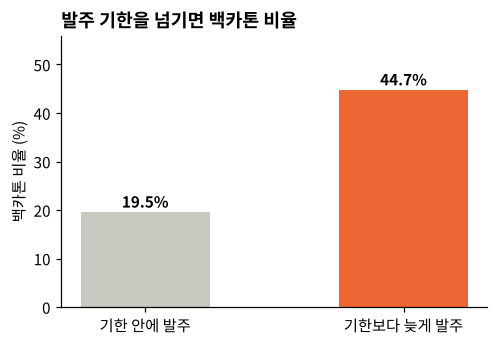

In [11]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.bar(check["발주_시점"], check["백카톤_비율"], color=[GRAY, ORANGE], width=0.5)
for x, v in enumerate(check["백카톤_비율"]):
    ax.text(x, v + 1, f"{v}%", ha="center", fontweight="bold")
ax.set_ylim(0, check["백카톤_비율"].max() * 1.25)
ax.set_title("발주 기한을 넘기면 백카톤 비율"); ax.set_ylabel("백카톤 비율 (%)")
plt.show()

→ 기한을 넘겨 발주한 줄은 백카톤이 될 비율이 **2배 이상** → 발주 기한 알림 기준으로 사용

### 3-③ 새 오더가 들어오면 — 권장 발주량 + 위험도
예시 오더 5줄을 넣고 `reorder_recommendation` 뷰로 확인합니다.

- 권장 발주량 = MAX(오더 수량 − 잔여 재고, 0)
- 위험도: 오늘이 발주 기한을 넘었으면 **높음**, 3일 안이면 **중간**

In [12]:
con.execute("DELETE FROM incoming_orders")
con.executemany("INSERT INTO incoming_orders VALUES (?,?,?,?,?)", [
    ("S-DEMO01-01-24", "64667109",     80,  "2024-06-28", "2024-06-10"),  # 재고 충분
    ("S-DEMO01-01-24", "95154-39627",  150, "2024-06-28", "2024-06-10"),  # 일부만 재고
    ("S-DEMO01-01-24", "0K19A-86-609", 50,  "2024-06-25", "2024-06-10"),  # 기한 지남
    ("S-DEMO01-01-24", "0K21A45420",   40,  "2024-06-30", "2024-06-10"),  # 기한 임박 (하이픈 없는 표기)
    ("S-DEMO01-01-24", "0K23A-10-586", 30,  "2024-07-20", "2024-06-10"),  # 여유
])
sql("""
SELECT part_no AS 품번, order_qty AS 오더, free_stock AS 잔여재고,
       use_from_stock AS 재고사용, recommended_po_qty AS 권장발주,
       supplier AS 거래처, p80_lead AS P80, order_by_date AS 발주기한, risk AS 위험도
FROM reorder_recommendation
""")

,품번,오더,잔여재고,재고사용,권장발주,거래처,P80,발주기한,위험도
0,64667109,80,120.0,80.0,0.0,공급사18,18,2024-06-10,재고로 충당
1,95154-39627,150,97.0,97.0,53.0,공급사07,18,2024-06-10,중간
2,0K19A-86-609,50,0.0,0.0,50.0,공급사24,18,2024-06-07,높음
3,0K21A45420,40,0.0,0.0,40.0,공급사17,18,2024-06-12,중간
4,0K23A-10-586,30,0.0,0.0,30.0,공급사15,18,2024-07-02,낮음


### 3-④ 과거에 중복 구매는 없었을까?
같은 품목을 **재사용**한 날 앞뒤 14일 안에 또 **새로 산** 줄 = 재고가 있었는데 산 후보

In [13]:
sql("""
WITH reuse AS MATERIALIZED (
    SELECT DISTINCT part_key, po_date FROM order_lines
    WHERE extract_type = '발주' AND bc_kind = 'BC_REUSE'),
buy AS MATERIALIZED (
    SELECT part_key, po_date, po_amount, ROW_NUMBER() OVER () AS id FROM order_lines
    WHERE extract_type = '발주' AND (bc_kind = 'BC_REPURCHASE' OR line_type = 'NEW')),
dup AS (
    SELECT DISTINCT b.id, b.part_key, b.po_amount
    FROM buy b JOIN reuse r
      ON r.part_key = b.part_key
     AND ABS(JULIANDAY(r.po_date) - JULIANDAY(b.po_date)) <= 14)
SELECT COUNT(DISTINCT part_key) AS 품목수, COUNT(*) AS 줄수,
       ROUND(SUM(po_amount) / 1000000.0, 1) AS 금액_백만원
FROM dup
""")

,품목수,줄수,금액_백만원
0,12,14,23.8


### 3-⑤ 그래서 지금 뭘 해야 할까 — 품목별 다음 액션
검토일 기준으로 품목마다 할 일을 붙입니다. 기준은 `review_settings` 표(기준일 · 배수 1.5 · 최근 3개월)에서 바꿀 수 있습니다.

| 상태 | 판단 기준 | 액션 |
|---|---|---|
| 과다재고 | 잔여 재고 + 입고 예정 > 대기 바이어 오더 + 월평균 오더 × 1.5 | 입고 중단 · 수량 축소 |
| 미입고 지연 | 미입고인데 발주일 + 거래처 P80 경과 (과다재고 품목 제외) | 거래처 독촉 |
| 발주 필요 | 3-③의 위험도 높음·중간 | 발주 (기한까지) |
| 과다재고 | 입고 예정 없이 꾸준히 팔리는 품목의 재고가 1.5개월 치 초과 | 신규 발주 보류 |

In [14]:
sql("""
SELECT status AS 상태,
       CASE WHEN action LIKE '입고 수량 축소%' THEN '입고 수량 축소'
            WHEN action LIKE '발주 (%' THEN '발주' ELSE action END AS 액션,
       COUNT(*) AS 건수
FROM action_list
GROUP BY 1, 2
ORDER BY MIN(priority), 건수 DESC
""")

,상태,액션,건수
0,과다재고,입고 중단 · 발주 취소 협의,3
1,미입고 지연,거래처 독촉,7
2,발주 필요,발주,3
3,과다재고,신규 발주 보류 · 재고 우선 사용,23


In [15]:
sql("""
SELECT status AS 상태, action AS 액션, part_no AS 품번, supplier AS 거래처,
       qty AS 수량, free_qty AS 잔여재고, note AS 이유
FROM action_list
WHERE priority < 3
ORDER BY priority
""")

,상태,액션,품번,거래처,수량,잔여재고,이유
0,과다재고,입고 중단 · 발주 취소 협의,64667109,공급사18,100.0,120.0,잔여 재고 120개 · 대기 오더 100개
1,과다재고,입고 중단 · 발주 취소 협의,0K40A-40-199,공급사06,4.0,20.0,잔여 재고 20개 · 대기 오더 4개
2,과다재고,입고 중단 · 발주 취소 협의,297544,공급사02,6.0,118.0,잔여 재고 118개 · 대기 오더 6개
3,미입고 지연,거래처 독촉,35697535,공급사03,100.0,15.0,P80(18일) 기준 25일 초과
4,미입고 지연,거래처 독촉,68854192,공급사23,80.0,9.0,P80(14일) 기준 29일 초과
5,미입고 지연,거래처 독촉,0K40A-51-670,공급사10,50.0,0.0,P80(18일) 기준 25일 초과
6,미입고 지연,거래처 독촉,30042110,공급사07,2.0,0.0,P80(18일) 기준 25일 초과
7,미입고 지연,거래처 독촉,39245-F4667,공급사02,400.0,0.0,P80(18일) 기준 36일 초과
8,미입고 지연,거래처 독촉,975150,공급사02,100.0,0.0,P80(18일) 기준 36일 초과
9,미입고 지연,거래처 독촉,74159-E4854,공급사25,50.0,3.0,P80(18일) 기준 27일 초과


## 정리

| 발견 | 다음 행동 |
|---|---|
| 백카톤 절반 이상이 **입고 지연** | 거래처별 P80으로 발주 기한 알림 |
| 기한 넘긴 발주는 백카톤 비율 **2배 이상** | 새 오더마다 위험도(높음/중간/낮음) 표시 |
| 입고됐는데 안 실린 줄 상당수가 **8일 이상 전 입고** | 선적 전 재고 배정 체크리스트 |
| 재사용 직후 **재구매** 사례 존재 | 발주 전 잔여 재고 먼저 차감 |
| 남는 입고 예정 · 늦어지는 미입고 | 품목별 액션: **입고 중단** · **거래처 독촉** · 발주 |

**한계**: 재고 파일이 한 시점뿐이라 과거 재고는 ±14일 재사용 기록으로 간접 추정.
선적 예정일은 바이어·영업 협의값을 입력으로 받음. 권장값은 참고용이며 최종 판단은 담당자.